In [20]:
!pip install librosa soundfile numpy pandas matplotlib seaborn scikit-learn tensorflow

In [21]:
import os
import numpy as np
import pandas as pd

import librosa

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.preprocessing.sequence import pad_sequences

In [22]:
dataset_path = r"D:\AIML Assignments\Week-4\Question-5\RAVDESS"


print(os.listdir(dataset_path)[:5])

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


In [23]:
emotion_dict = {

'01':'neutral',
'02':'calm',
'03':'happy',
'04':'sad',
'05':'angry',
'06':'fearful',
'07':'disgust',
'08':'surprised'

}

In [24]:
data=[]


for actor in os.listdir(dataset_path):

    actor_path=os.path.join(dataset_path,actor)


    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):


                emotion_code=file.split("-")[2]


                emotion=emotion_dict[emotion_code]


                data.append(
                    [
                    os.path.join(actor_path,file),
                    emotion
                    ]
                )


df=pd.DataFrame(
    data,
    columns=["path","emotion"]
)


df.head()

,path,emotion
0,D:\AIML Assignments\Week-4\Question-5\RAVDESS\...,neutral
1,D:\AIML Assignments\Week-4\Question-5\RAVDESS\...,neutral
2,D:\AIML Assignments\Week-4\Question-5\RAVDESS\...,neutral
3,D:\AIML Assignments\Week-4\Question-5\RAVDESS\...,neutral
4,D:\AIML Assignments\Week-4\Question-5\RAVDESS\...,calm


In [25]:
print(df.shape)

df["emotion"].value_counts()

(1440, 2)


emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64

In [26]:
def extract_features(file):

    audio,sr=librosa.load(
        file,
        duration=3
    )


    mfcc=librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )


    return mfcc.T

In [27]:
X=[]
y=[]


for index,row in df.iterrows():

    feature=extract_features(row["path"])

    X.append(feature)

    y.append(row["emotion"])



print(len(X))

1440


In [28]:
X=pad_sequences(
    X,
    maxlen=130,
    padding="post",
    dtype="float32"
)


X=np.array(X)


print(X.shape)

(1440, 130, 40)


In [29]:
encoder=LabelEncoder()


y=encoder.fit_transform(y)


y=to_categorical(y)


print(y.shape)

(1440, 8)


In [30]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print(X_train.shape)

(1152, 130, 40)


In [31]:
model=Sequential()


model.add(
    LSTM(
        128,
        input_shape=(130,40)
    )
)


model.add(
    Dropout(0.3)
)


model.add(
    Dense(
        64,
        activation="relu"
    )
)


model.add(
    Dense(
        8,
        activation="softmax"
    )
)


model.summary()

D:\Anaconda\envs\opencv-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 128)                 │          86,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,304 (372.28 KB)

 Trainable params: 95,304 (372.28 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
history=model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test,y_test)
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 16s 137ms/step - accuracy: 0.1823 - loss: 2.0585 - val_accuracy: 0.2604 - val_loss: 1.9740
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 441ms/step - accuracy: 0.2257 - loss: 1.9504 - val_accuracy: 0.2882 - val_loss: 1.8028
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 465ms/step - accuracy: 0.2839 - loss: 1.8482 - val_accuracy: 0.3889 - val_loss: 1.6949
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 473ms/step - accuracy: 0.3090 - loss: 1.7785 - val_accuracy: 0.3958 - val_loss: 1.6335
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 404ms/step - accuracy: 0.3333 - loss: 1.7103 - val_accuracy: 0.3646 - val_loss: 1.6057
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 431ms/step - accuracy: 0.3351 - loss: 1.6604 - val_accuracy: 0.4410 - val_loss: 1.5390
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 430ms/step - accuracy: 0.3681 - loss: 1.6026 - val_accuracy: 0.4340 - val_loss: 1.5036
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 475ms/step - accuracy: 0.3819 - loss: 1.5864 - val_accu

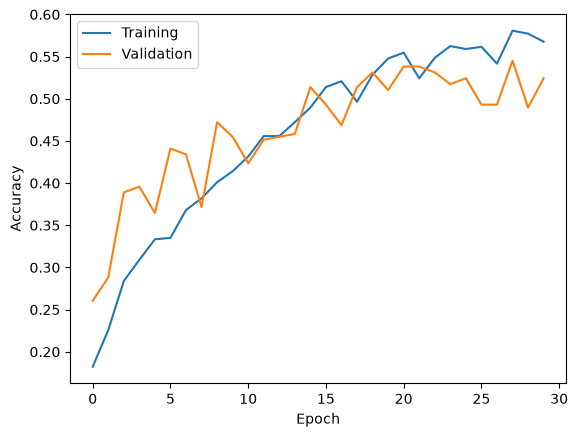

In [34]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.legend(
["Training","Validation"]
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [35]:
prediction=model.predict(X_test)


predicted=np.argmax(
    prediction,
    axis=1
)


actual=np.argmax(
    y_test,
    axis=1
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


In [36]:
accuracy=accuracy_score(
    actual,
    predicted
)


print("Accuracy:",accuracy)

Accuracy: 0.5243055555555556


In [37]:
print(
classification_report(
    actual,
    predicted,
    target_names=encoder.classes_
)
)

              precision    recall  f1-score   support

       angry       0.70      0.62      0.66        42
        calm       0.60      0.75      0.67        44
     disgust       0.44      0.66      0.53        32
     fearful       0.44      0.47      0.45        32
       happy       0.57      0.38      0.46        34
     neutral       0.41      0.60      0.49        20
         sad       0.32      0.21      0.25        39
   surprised       0.62      0.51      0.56        45

    accuracy                           0.52       288
   macro avg       0.51      0.52      0.51       288
weighted avg       0.53      0.52      0.52       288



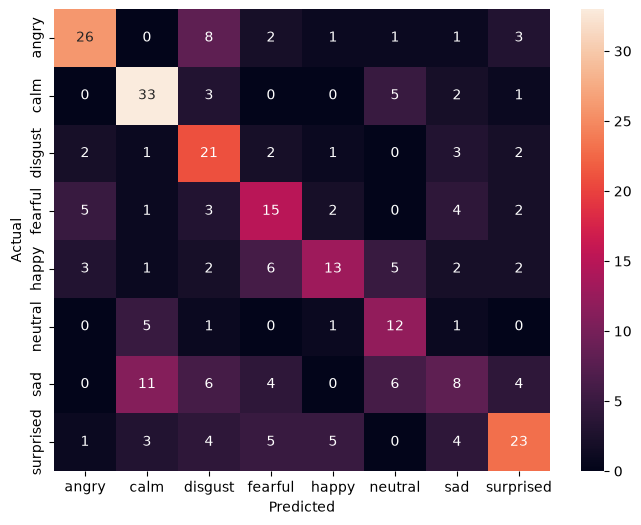

In [38]:
cm=confusion_matrix(
    actual,
    predicted
)


plt.figure(figsize=(8,6))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)


plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
print("==============================")
print("Final Model Evaluation")
print("==============================")


print(
    "Accuracy:",
    accuracy_score(actual,predicted)
)


print("\nClassification Report:\n")


print(
classification_report(
    actual,
    predicted,
    target_names=encoder.classes_
)
)

Final Model Evaluation
Accuracy: 0.5243055555555556

Classification Report:

              precision    recall  f1-score   support

       angry       0.70      0.62      0.66        42
        calm       0.60      0.75      0.67        44
     disgust       0.44      0.66      0.53        32
     fearful       0.44      0.47      0.45        32
       happy       0.57      0.38      0.46        34
     neutral       0.41      0.60      0.49        20
         sad       0.32      0.21      0.25        39
   surprised       0.62      0.51      0.56        45

    accuracy                           0.52       288
   macro avg       0.51      0.52      0.51       288
weighted avg       0.53      0.52      0.52       288



In [40]:
model.save(
    "Speech_Emotion_LSTM_Model.h5"
)

print("Model Saved Successfully")

Model Saved Successfully


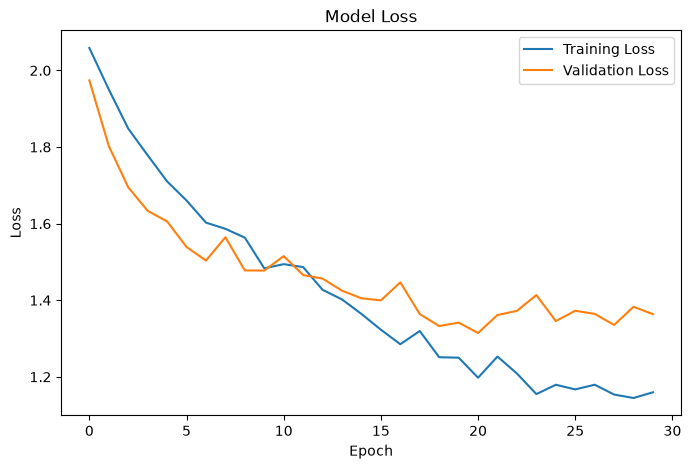

In [41]:
plt.figure(figsize=(8,5))


plt.plot(
    history.history["loss"]
)

plt.plot(
    history.history["val_loss"]
)


plt.legend(
["Training Loss","Validation Loss"]
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Model Loss")


plt.show()

Dataset Description

The RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) dataset is an open-source dataset used for speech emotion recognition. It contains 1440 speech recordings from 24 actors with 8 different emotion classes such as happy, sad, angry, calm, fearful, disgust, surprised, and neutral. This dataset was selected because it provides well-labeled emotional speech samples, making it suitable for training an LSTM-based emotion classification model.

Audio Preprocessing and Feature Extraction

The audio files were first loaded and processed using the Librosa library. MFCC (Mel Frequency Cepstral Coefficients) features were extracted from the audio signals because they represent important speech characteristics such as frequency and tone. Since audio samples have different lengths, padding was applied to make all feature sequences equal before providing them to the LSTM model.

LSTM Model Architecture

An LSTM (Long Short-Term Memory) model was used for emotion classification because it can learn patterns from sequential audio features. The model consists of an LSTM layer with 128 units, a dropout layer to reduce overfitting, a dense layer with ReLU activation, and an output layer with Softmax activation to classify the eight emotion categories.

Training Procedure

The extracted MFCC features were divided into training and testing datasets using an 80:20 split. The model was trained using the Adam optimizer and categorical cross-entropy loss function. The training process was performed for 30 epochs with a batch size of 16, and validation performance was monitored during training.

Evaluation Results

The trained LSTM model was evaluated using accuracy, precision, recall, F1-score, and confusion matrix. These metrics were used to measure how effectively the model classifies different emotional speech samples. The confusion matrix shows the correctly and incorrectly predicted emotion classes.